In [85]:
import pandas as pd #load data
import numpy as np #math alcumation
import re #regular expression to clean data remove un needed itams
import nltk #very important library for every function
import matplotlib.pyplot as plt #visualization
from nltk.corpus import stopwords #corpus is large set of data, stopwords = to remove verbs, unwanted words
from nltk. tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud


In [86]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [87]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)
print(df)

                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.
5      Poor quality product and terrible experience.
6                  Fast shipping and good packaging.
7        The product stopped working after two days.
8               Excellent service and great quality.
9            Late delivery and bad customer support.


In [88]:
print("Customer reviews dataset")
print(df.head())

Customer reviews dataset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [89]:
# Stopwords
stop_words = set(stopwords.words('english'))

# Text Cleaning Function
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words back into a sentence
    cleaned_text = " ".join(words)

    return cleaned_text

# Apply cleaning
df['Cleaned_Review'] = df['Review'].apply(clean_text)

print("\nCleaned Reviews:")
print(df[['Review', 'Cleaned_Review']])


Cleaned Reviews:
                                              Review                            Cleaned_Review
0  The product quality is excellent and delivery ...   product quality excellent delivery fast
1       Very bad packaging and the item was damaged.                bad packaging item damaged
2       Customer service was helpful and responsive.       customer service helpful responsive
3  The delivery was delayed and support team did ...     delivery delayed support team respond
4                  Amazing product. Worth the money.               amazing product worth money
5      Poor quality product and terrible experience.  poor quality product terrible experience
6                  Fast shipping and good packaging.              fast shipping good packaging
7        The product stopped working after two days.          product stopped working two days
8               Excellent service and great quality.           excellent service great quality
9            Late delivery and b

4. SENTIMENT ANALYSIS

In [90]:
sia = SentimentIntensityAnalyzer()
def analyze_sentiment(review):
  score = sia.polarity_scores(review)
  compound = score['compound']
  if compound >= 0.05:
    return "Positive"
  elif compound <= -0.05:
    return "Negative"
  else:
    return "Neutral"

    #Apply sentiment analysis
df['Sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)
print("\n Sentimental analysis results: ")
print(df[['Review', 'Sentiment']])


 Sentimental analysis results: 
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [91]:
all_words = " ".join(df['Cleaned_Review'])
word_list= all_words.split()
word_freq = Counter(word_list)
print("\n TOp 10 common Key words")
print(word_freq.most_common(10))


 TOp 10 common Key words
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [93]:
negative_reviews=df[df['Sentiment']=='Negative']

negative_words=" ".join(negative_reviews['Cleaned_Review'])

negative_word_list=negative_words.split()

complaint_freq=Counter(negative_word_list)

print("\nMost common complained")
print(complaint_freq.most_common(10))


Most common complained
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


In [94]:
sentiment_counts = df['Sentiment'].value_counts()
sentiment_counts

,count
Sentiment,
Positive,6
Negative,4


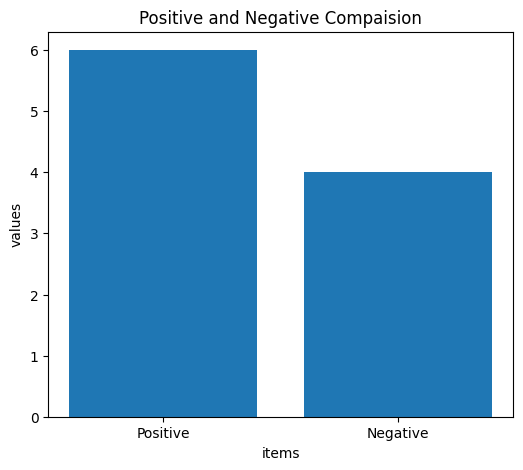

In [95]:
sentiment_counts = df['Sentiment']. value_counts()
plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Positive and Negative Compaision")
plt.xlabel("items")
plt.ylabel("values")
plt.show()

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

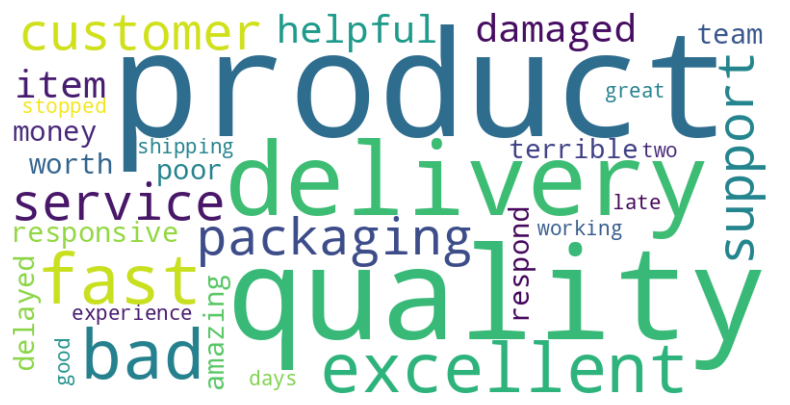

In [98]:
wordcloud = WordCloud(
    width = 800,
    height = 400,
    background_color = 'white'
).generate(all_words)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')